Dataset Shape: (569, 30)


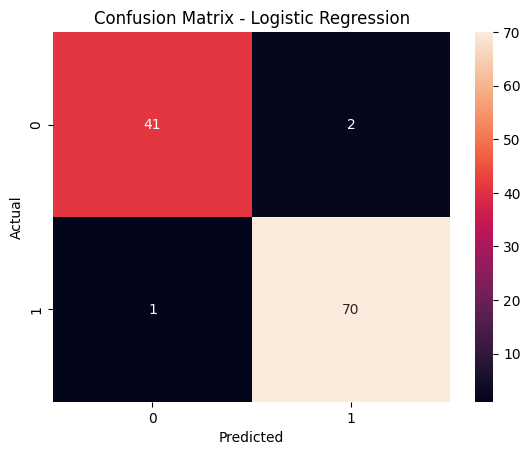

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



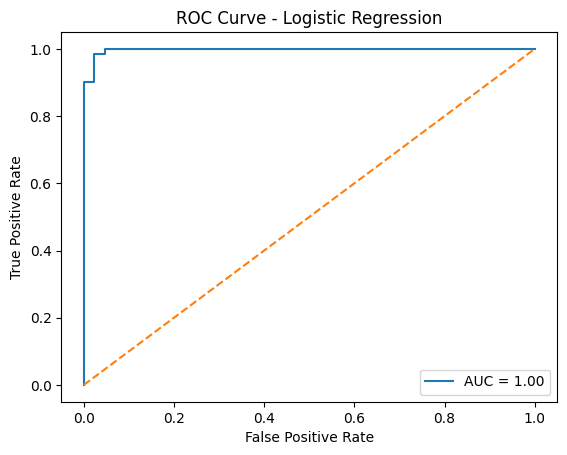

Classification Report (Imbalanced handled):
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        11
           1       0.97      0.99      0.98        71

    accuracy                           0.96        82
   macro avg       0.94      0.90      0.92        82
weighted avg       0.96      0.96      0.96        82

Decision Tree Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        43
           1       0.94      0.96      0.95        71

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



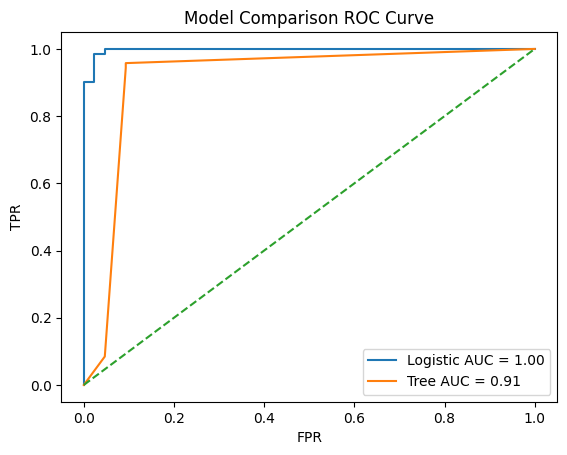

In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

# ==============================
# 2. LOAD DATASET
# ==============================
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)

# ==============================
# 3. TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 4. FEATURE SCALING
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 5. LOGISTIC REGRESSION MODEL
# ==============================
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

# ==============================
# 6. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==============================
# 7. CLASSIFICATION METRICS
# ==============================
print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred))

# ==============================
# 8. ROC CURVE & AUC
# ==============================
y_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

# ==============================
# 9. IMBALANCED DATA SIMULATION
# ==============================
from sklearn.utils import resample

# Combine X and y
df = pd.DataFrame(X)
df['target'] = y

# Separate classes
df_majority = df[df.target == 1]
df_minority = df[df.target == 0]

# Downsample minority (simulate imbalance)
df_minority_downsampled = resample(df_minority,
                                  replace=False,
                                  n_samples=50,
                                  random_state=42)

df_imbalanced = pd.concat([df_majority, df_minority_downsampled])

X_imb = df_imbalanced.drop('target', axis=1)
y_imb = df_imbalanced['target']

# Split again
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42
)

# Scale
X_train_i = scaler.fit_transform(X_train_i)
X_test_i = scaler.transform(X_test_i)

# ==============================
# 10. LOGISTIC WITH CLASS WEIGHT
# ==============================
log_balanced = LogisticRegression(class_weight='balanced', max_iter=5000)
log_balanced.fit(X_train_i, y_train_i)

y_pred_i = log_balanced.predict(X_test_i)

print("Classification Report (Imbalanced handled):")
print(classification_report(y_test_i, y_pred_i))

# ==============================
# 11. DECISION TREE MODEL
# ==============================
tree_model = DecisionTreeClassifier(max_depth=5)
tree_model.fit(X_train, y_train)

y_tree_pred = tree_model.predict(X_test)

print("Decision Tree Report:")
print(classification_report(y_test, y_tree_pred))

# ==============================
# 12. MODEL COMPARISON (AUC)
# ==============================
y_tree_prob = tree_model.predict_proba(X_test)[:,1]

fpr_tree, tpr_tree, _ = roc_curve(y_test, y_tree_prob)
auc_tree = roc_auc_score(y_test, y_tree_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"Logistic AUC = {auc_score:.2f}")
plt.plot(fpr_tree, tpr_tree, label=f"Tree AUC = {auc_tree:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Model Comparison ROC Curve")
plt.legend()
plt.show()